In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,...,Drama,Music,Biography,Romance,History,Crime,Western,War,Musical,Sport
0,0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,...,False,False,False,False,False,False,False,False,False,False
1,1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,...,False,False,False,False,False,False,False,False,False,False
2,2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,...,False,False,False,False,False,False,False,False,False,False
3,3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,...,False,False,False,False,False,False,False,False,False,False
4,4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.shape # second number = # of columns

(1000, 33)

[Text(0.5, 1.0, 'Average Ratings by Year')]

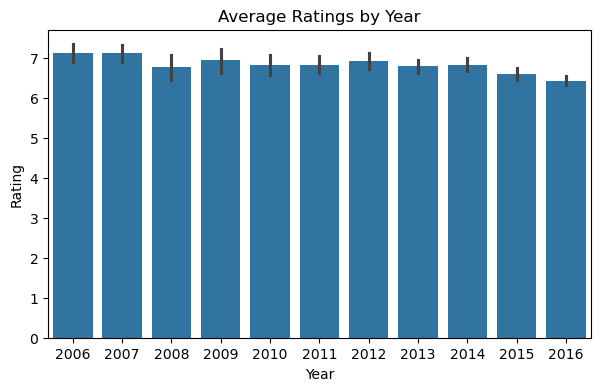

In [124]:
plt.figure(figsize=(7,4))
bar = sns.barplot(data = df, x = "Year", y = "Rating")
bar.set(title = "Average Ratings by Year")

In [125]:
years = sorted(df["Year"].unique())
ratings_yr = [df.loc[df["Year"] == year, "Rating"] for year in years]
f, p = stats.f_oneway(*ratings_yr)
print(f"f = {f:.4f}, p = {p:4f}")

f = 6.0455, p = 0.000000


In [126]:
dfb = len(years) - 1
dfw = len(df) - len(years)
alpha = 0.05
crit_f = stats.f.ppf(1 - alpha, dfb, dfw)
print(f"critical f = {crit_f:.4f}")

# statistically significant because p < 0.05
# f value surpassed the critcal f so

critical f = 1.8403


In [127]:
tukey = stats.tukey_hsd(*ratings_yr)
print(tukey)
print(years)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.009     1.000    -0.616     0.598
 (0 - 2)      0.340     0.779    -0.269     0.950
 (0 - 3)      0.164     0.999    -0.448     0.777
 (0 - 4)      0.298     0.870    -0.292     0.889
 (0 - 5)      0.287     0.889    -0.298     0.872
 (0 - 6)      0.200     0.991    -0.383     0.783
 (0 - 7)      0.313     0.751    -0.234     0.859
 (0 - 8)      0.287     0.827    -0.253     0.827
 (0 - 9)      0.523     0.048     0.002     1.043
 (0 - 10)      0.688     0.000     0.208     1.169
 (1 - 0)      0.009     1.000    -0.598     0.616
 (1 - 2)      0.349     0.690    -0.232     0.930
 (1 - 3)      0.173     0.997    -0.411     0.757
 (1 - 4)      0.307     0.799    -0.254     0.868
 (1 - 5)      0.296     0.825    -0.259     0.851
 (1 - 6)      0.209     0.980    -0.344     0.762
 (1 - 7)      0.322     0.635    -0.192     0.836
 (1 - 8)      0.296     0.728    -0.211    

In [4]:
tukey = pairwise_tukeyhsd(
    endog = df["Rating"],
    groups = df["Year"],
    alpha = 0.05
)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
2006,2007,0.009,1.0,-0.598,0.6159,False
2006,2008,-0.3404,0.7793,-0.95,0.2692,False
2006,2009,-0.1642,0.9987,-0.7765,0.4481,False
2006,2010,-0.2983,0.8695,-0.889,0.2923,False
2006,2011,-0.2869,0.8894,-0.8716,0.2978,False
2006,2012,-0.2,0.9905,-0.7828,0.3828,False
2006,2013,-0.3129,0.7512,-0.8594,0.2335,False
2006,2014,-0.2872,0.8273,-0.8273,0.2528,False
2006,2015,-0.5226,0.0481,-1.0432,-0.002,True
2006,2016,-0.6883,0.0002,-1.169,-0.2076,True


In [128]:
tukey = pairwise_tukeyhsd(
    endog = df["Rating"],
    groups = df["Year"],
    alpha = 0.05
)
tukey.summary()
tukey_df = pd.DataFrame(data = tukey._results_table.data[1:], columns = tukey._results_table.data[0])
tukey_df
tukey_df[tukey_df["reject"] == True]

,group1,group2,meandiff,p-adj,lower,upper,reject
8,2006,2015,-0.5226,0.0481,-1.0432,-0.0020,True
9,2006,2016,-0.6883,0.0002,-1.1690,-0.2076,True
17,2007,2015,-0.5316,0.0192,-1.0183,-0.0449,True
18,2007,2016,-0.6973,0.0000,-1.1410,-0.2535,True
33,2009,2016,-0.5241,0.0086,-0.9752,-0.0730,True
48,2012,2016,-0.4883,0.0061,-0.8984,-0.0782,True
51,2013,2016,-0.3754,0.0293,-0.7320,-0.0188,True
53,2014,2016,-0.4011,0.0092,-0.7477,-0.0544,True


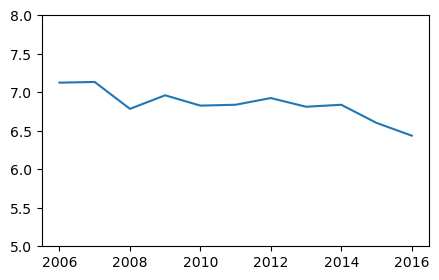

In [129]:
years = sorted(df["Year"].unique())
plot_points = [df.loc[df["Year"]==y, "Rating"].mean() for y in years]
plt.figure(figsize=(5,3))
plt.plot(years, plot_points)
plt.ylim(5,8)
plt.show()

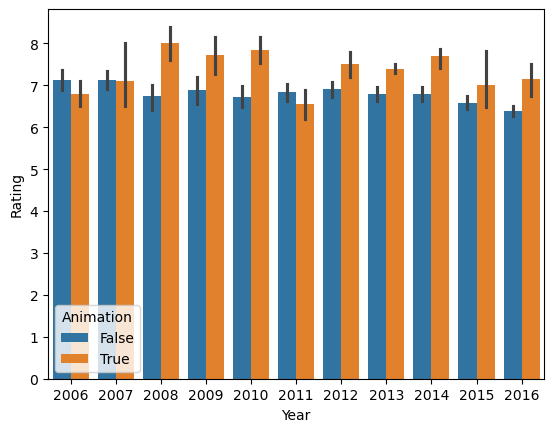

In [130]:
bar = sns.barplot(data=df, x="Year", y="Rating", hue="Animation")

In [131]:
animated = df.loc[df["Animation"]==True, "Rating"]
non_animated = df.loc[df["Animation"]==False, "Rating"]

t, p = stats.ttest_ind(animated, non_animated)
degf = len(animated) + len(non_animated) - 2
crit_t = stats.t.ppf(1 - alpha / 2, degf)
print(f"t = {t:.4f}, crit_t = {crit_t:.4f}, p = {p:.4f}")

t = 4.6113, crit_t = 1.9623, p = 0.0000


Text(0.5, 0.2, 't = 4.6113, \ncrit_t = 1.9623, \np = 0.0000')

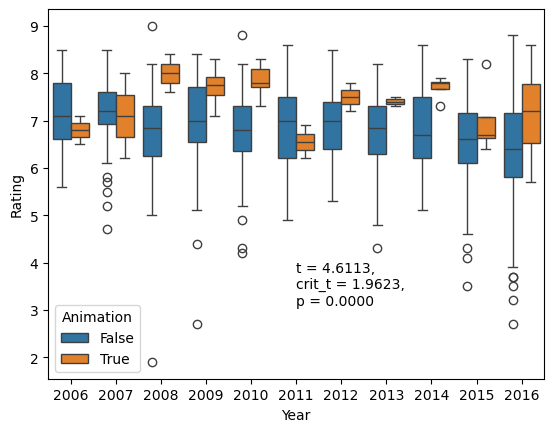

In [132]:
box = sns.boxplot(data=df, x="Year", y="Rating", hue="Animation")
box.text(x=0.5, y=0.2, s=f"t = {t:.4f}, \ncrit_t = {crit_t:.4f}, \np = {p:.4f}", transform = box.transAxes)

In [133]:
groups = [
    ["Action", "Adventure", "Sci-Fi"],
    ["Drama"],
    ["Comedy", "Romance"],
    ["Animation", "Adventure", "Comedy"],
]
df["Genre"] = df["Genre"].apply(lambda x: x.split(","))
df["Genre"]

0       [Action, Adventure, Sci-Fi]
1      [Adventure, Mystery, Sci-Fi]
2                [Horror, Thriller]
3       [Animation, Comedy, Family]
4      [Action, Adventure, Fantasy]
                   ...             
995         [Crime, Drama, Mystery]
996                        [Horror]
997         [Drama, Music, Romance]
998             [Adventure, Comedy]
999       [Comedy, Family, Fantasy]
Name: Genre, Length: 1000, dtype: object

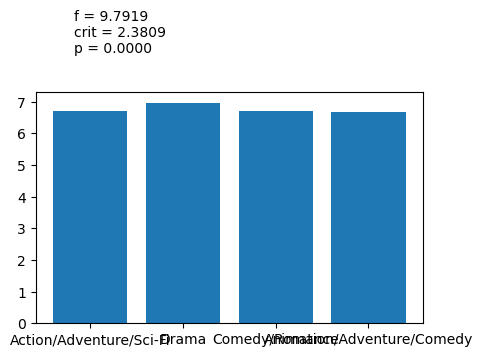

In [134]:
group_samples = [df.loc[df["Genre"].apply(lambda x: bool(set(x) & set(g))), "Rating"] for g in groups]
f,p = stats.f_oneway(*group_samples)
dfb = len(group_samples)
dfw = len(df) - len(group_samples)
crit = stats.f.ppf(1-alpha, dfb, dfw)
text = f"""f = {f:.4f}
crit = {crit:.4f}
p = {p:.4f}
"""
plt.figure(figsize=(5,3))
cols = ["/".join(g) for g in groups]
heights = [s.mean() for s in group_samples]
plt.bar(x=cols, height = heights)
plt.text(x=0.1, y=1.1, s=text, transform=plt.gca().transAxes)
plt.show()